<a href="https://colab.research.google.com/github/ABamukhayyar/AI_stock_Market_Prediction/blob/main/TASI_Sentiment_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Block 1: Install Dependencies
!pip install feedparser httpx beautifulsoup4 lxml transformers torch -q

import warnings
warnings.filterwarnings('ignore')
print("✅ Dependencies installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.9 MB/s eta 0:00:00
✅ Dependencies installed


In [2]:
# Block 2: Load Translation Model + FinBERT
# Models saved to Google Drive on first run — loads instantly after that
from transformers import pipeline, MarianMTModel, MarianTokenizer
import torch, os

device = 0 if torch.cuda.is_available() else -1
print(f"Using: {'GPU ✅' if device == 0 else 'CPU (Go to Runtime > Change runtime type > T4 GPU)'}")

DRIVE_BASE    = "/content/drive/MyDrive/TASI_Models"
TRANSLATE_DIR = f"{DRIVE_BASE}/opus-mt-ar-en"
FINBERT_DIR   = f"{DRIVE_BASE}/finbert"
os.makedirs(DRIVE_BASE, exist_ok=True)

# Arabic → English translation
if os.path.exists(f"{TRANSLATE_DIR}/config.json"):
    print("Loading translation model from Drive... ✅")
    tokenizer   = MarianTokenizer.from_pretrained(TRANSLATE_DIR)
    ar_en_model = MarianMTModel.from_pretrained(TRANSLATE_DIR)
else:
    print("Downloading translation model (first time only ~300MB)...")
    tokenizer   = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ar-en")
    ar_en_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-ar-en")
    tokenizer.save_pretrained(TRANSLATE_DIR)
    ar_en_model.save_pretrained(TRANSLATE_DIR)
    print("✅ Translation model saved to Drive")

if device == 0:
    ar_en_model = ar_en_model.cuda()

def translate_ar_to_en(text):
    try:
        tokens = tokenizer([text[:400]], return_tensors="pt", padding=True, truncation=True, max_length=128)
        if device == 0:
            tokens = {k: v.cuda() for k, v in tokens.items()}
        translated = ar_en_model.generate(**tokens, max_new_tokens=128)
        return tokenizer.decode(translated[0], skip_special_tokens=True)
    except:
        return text

# FinBERT financial sentiment
if os.path.exists(f"{FINBERT_DIR}/config.json"):
    print("Loading FinBERT from Drive... ✅")
    finbert = pipeline("text-classification", model=FINBERT_DIR, device=device, truncation=True, max_length=512)
else:
    print("Downloading FinBERT (first time only ~440MB)...")
    finbert = pipeline("text-classification", model="ProsusAI/finbert", device=device, truncation=True, max_length=512)
    finbert.model.save_pretrained(FINBERT_DIR)
    finbert.tokenizer.save_pretrained(FINBERT_DIR)
    print("✅ FinBERT saved to Drive")

print("="*50)
print("✅ Models ready")
print(f"   Saved to: {DRIVE_BASE}")
print("="*50)

Using: CPU (Go to Runtime > Change runtime type > T4 GPU)


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/917k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ FinBERT saved to Drive
✅ Models ready
   Saved to: /content/drive/MyDrive/TASI_Models


In [3]:
# Block 3: Fetch TASI News from Google News RSS
import feedparser, httpx
from datetime import datetime, timedelta, timezone
from bs4 import BeautifulSoup

RSS_FEEDS = [
    # Arabic
    {"url": "https://news.google.com/rss/search?q=تاسي+سوق+الأسهم+السعودية&hl=ar&gl=SA&ceid=SA:ar",   "lang": "ar", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=مؤشر+تداول+اليوم&hl=ar&gl=SA&ceid=SA:ar",           "lang": "ar", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=سوق+الأسهم+السعودي+اليوم&hl=ar&gl=SA&ceid=SA:ar",   "lang": "ar", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=اقتصاد+السعودية+أسهم&hl=ar&gl=SA&ceid=SA:ar",       "lang": "ar", "priority": 9},
    {"url": "https://news.google.com/rss/search?q=أرامكو+سابك+بنوك+سعودية&hl=ar&gl=SA&ceid=SA:ar",    "lang": "ar", "priority": 9},
    {"url": "https://news.google.com/rss/search?q=البنوك+السعودية+أرباح&hl=ar&gl=SA&ceid=SA:ar",       "lang": "ar", "priority": 8},
    {"url": "https://news.google.com/rss/search?q=النفط+أسعار+أوبك+السعودية&hl=ar&gl=SA&ceid=SA:ar",   "lang": "ar", "priority": 8},
    {"url": "https://news.google.com/rss/search?q=تداول+ارتفاع+انخفاض+مؤشر&hl=ar&gl=SA&ceid=SA:ar",    "lang": "ar", "priority": 7},
    # English
    {"url": "https://news.google.com/rss/search?q=TASI+Tadawul+Saudi+stock&hl=en-US&gl=US&ceid=US:en",          "lang": "en", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=Saudi+stock+market+today&hl=en-US&gl=US&ceid=US:en",          "lang": "en", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=Tadawul+index+Saudi+Arabia&hl=en-US&gl=US&ceid=US:en",        "lang": "en", "priority": 10},
    {"url": "https://news.google.com/rss/search?q=Saudi+Arabia+economy+investment&hl=en-US&gl=US&ceid=US:en",   "lang": "en", "priority": 9},
    {"url": "https://news.google.com/rss/search?q=Aramco+stock+Saudi+earnings&hl=en-US&gl=US&ceid=US:en",       "lang": "en", "priority": 9},
    {"url": "https://news.google.com/rss/search?q=OPEC+oil+price+Saudi+Arabia&hl=en-US&gl=US&ceid=US:en",       "lang": "en", "priority": 8},
    {"url": "https://news.google.com/rss/search?q=Saudi+Vision+2030+economy+growth&hl=en-US&gl=US&ceid=US:en",  "lang": "en", "priority": 8},
    {"url": "https://news.google.com/rss/search?q=Saudi+banks+finance+market&hl=en-US&gl=US&ceid=US:en",        "lang": "en", "priority": 7},
    {"url": "https://news.google.com/rss/search?q=Middle+East+Gulf+stock+market&hl=en-US&gl=US&ceid=US:en",     "lang": "en", "priority": 6},
]

KEYWORDS_AR = ["تاسي","تداول","سوق الأسهم","الأسهم السعودية","أرامكو","سابك",
               "اقتصاد","رؤية 2030","النفط","مؤشر","بنوك","ربح","ارتفاع","انخفاض"]
KEYWORDS_EN = ["TASI","Tadawul","Saudi stock","Saudi market","Aramco","SABIC",
               "Saudi Arabia","Vision 2030","OPEC","oil price","Saudi banks",
               "Riyadh","Saudi economy","Gulf market"]

# Must contain a Saudi-specific term — blocks Vietnam/Nasdaq/Dollar index articles
MUST_SAUDI_AR = ["تاسي","تداول","الأسهم السعودية","السوق السعودية",
                 "سوق الأسهم السعودية","أرامكو","سابك","السعودية"]
MUST_SAUDI_EN = ["TASI","Tadawul","Saudi","Aramco","SABIC","Riyadh","Gulf"]

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
           "Accept-Language": "ar,en;q=0.9"}

def clean_html(text):
    if text and "<" in text:
        return BeautifulSoup(text, "lxml").get_text(separator=" ").strip()
    return text or ""

def is_recent(entry, days=3):
    cutoff = datetime.now(timezone.utc) - timedelta(days=days)
    for attr in ("published_parsed", "updated_parsed"):
        t = getattr(entry, attr, None)
        if t:
            try: return datetime(*t[:6], tzinfo=timezone.utc) >= cutoff
            except: pass
    return True

all_articles = []
for cfg in RSS_FEEDS:
    try:
        with httpx.Client(timeout=20, follow_redirects=True, headers=headers) as client:
            resp = client.get(cfg["url"])
        feed  = feedparser.parse(resp.text)
        count = 0
        for e in feed.entries:
            if not is_recent(e): continue
            title   = getattr(e, "title",   "").strip()
            summary = clean_html(getattr(e, "summary", ""))
            text    = (title + " " + summary).lower()
            kws       = KEYWORDS_AR   if cfg["lang"] == "ar" else KEYWORDS_EN
            must_list = MUST_SAUDI_AR if cfg["lang"] == "ar" else MUST_SAUDI_EN
            if len(title) >= 10 and any(k.lower() in text for k in kws) and any(m.lower() in text for m in must_list):
                all_articles.append({"title": title, "summary": summary[:400],
                                     "lang": cfg["lang"], "priority": cfg["priority"]})
                count += 1
        print("  [" + cfg["lang"].upper() + "] " + str(count) + " articles")
    except Exception as ex:
        print("  Failed: " + str(ex))

seen, unique = set(), []
for a in sorted(all_articles, key=lambda x: -x["priority"]):
    key = a["title"][:60].lower()
    if key not in seen:
        seen.add(key)
        unique.append(a)
articles = unique[:40]

ar_count = sum(1 for a in articles if a["lang"] == "ar")
en_count = sum(1 for a in articles if a["lang"] == "en")

print("="*50)
print("📰 ARTICLES FETCHED SUCCESSFULLY")
print("   Arabic  : " + str(ar_count))
print("   English : " + str(en_count))
print("   Total   : " + str(len(articles)))
print("="*50)

if len(articles) < 3:
    raise Exception("❌ Not enough articles — check internet connection")

  [AR] 25 articles
  [AR] 0 articles
  [AR] 13 articles
  [AR] 4 articles
  [AR] 0 articles
  [AR] 0 articles
  [AR] 1 articles
  [AR] 1 articles
  [EN] 0 articles
  [EN] 2 articles
  [EN] 3 articles
  [EN] 0 articles
  [EN] 0 articles
  [EN] 0 articles
  [EN] 1 articles
  [EN] 0 articles
  [EN] 1 articles
📰 ARTICLES FETCHED SUCCESSFULLY
   Arabic  : 34
   English : 6
   Total   : 40


In [4]:
# Block 4: Translate Arabic → English, Score with Hybrid (Lexicon + FinBERT)
import numpy as np

# Full Arabic financial lexicon with all word forms
ARABIC_LEXICON = {
    # Bullish +2
    "ارتفع":2, "ارتفاع":2, "ارتفاعا":2, "ارتفاعاً":2,
    "يرتفع":2, "ترتفع":2, "مرتفع":2, "مرتفعا":2, "مرتفعاً":2, "مرتفعة":2, "مرتفعةً":2,
    "صعود":2, "يصعد":2, "تصعد":2, "صعد":2,
    "مكاسب":2, "ربح":2, "يربح":2, "تربح":2, "أرباح":2,
    "نمو":2, "ينمو":2, "تنمو":2,
    "قفز":2, "يقفز":2, "تقفز":2,
    "تحسن":2, "إيجابي":2, "إيجابية":2, "إيجابياً":2,
    "تعافى":2, "تعافي":2, "انتعاش":2, "ينتعش":2, "تنتعش":2,
    "يحقق":2, "تحقق":2, "يسجل":2, "تسجل":2, "سجل":2,
    "يكسب":2, "تكسب":2, "مكسب":2, "يعوض":1,
    # Bullish +1
    "دعم":1, "مستقر":1, "قوي":1, "متماسك":1,
    # Neutral (closing/ending verbs — no directional signal)
    "يغلق":0, "تغلق":0, "أغلق":0, "ينهي":0, "تنهي":0,
    # Bearish -2
    "انخفض":-2, "انخفاض":-2, "انخفاضا":-2, "انخفاضاً":-2,
    "ينخفض":-2, "تنخفض":-2,
    "هبوط":-2, "يهبط":-2, "تهبط":-2, "هبط":-2,
    "خسارة":-2, "خسائر":-2, "يخسر":-2, "تخسر":-2,
    "تراجع":-2, "يتراجع":-2, "تتراجع":-2,
    "سقط":-2, "سقوط":-2, "يسقط":-2,
    "تدهور":-2, "انهيار":-2,
    # Bearish -1
    "ضغوط":-1, "مخاوف":-1, "توترات":-1, "تذبذب":-1,
    "تقلب":-1, "ضعيف":-1, "قلق":-1, "مخاطر":-1, "ضغط":-1,
}

def normalize_arabic(word):
    """Strip punctuation, diacritics (tashkeel), and ال prefix for lexicon lookup."""
    import unicodedata
    w = word.strip("«»،,.'\"()[]{}،؛")
    # Remove all Arabic diacritics (tashkeel: fatha, damma, kasra, tanwin, shadda, sukun)
    diacritics = "\u064B\u064C\u064D\u064E\u064F\u0650\u0651\u0652\u0653\u0654\u0655"
    for d in diacritics:
        w = w.replace(d, "")
    # Strip ال definite article prefix
    if w.startswith("ال") and len(w) > 3:
        w = w[2:]
    return w

def score_arabic_lexicon(text):
    words = text.split()
    total, hits = 0, 0
    for word in words:
        w = normalize_arabic(word)
        if w in ARABIC_LEXICON:
            val = ARABIC_LEXICON[w]
            if val != 0:
                total += val
                hits  += 1
    if hits == 0:
        return None
    return max(-1.0, min(1.0, total / (hits * 2)))

def score_finbert(text):
    try:
        result = finbert(text[:512])[0]
        label  = result["label"].lower()
        conf   = result["score"]
        if label == "positive":  return  conf
        elif label == "negative": return -conf
        else:                     return  0.0
    except:
        return 0.0

print("Translating and scoring " + str(len(articles)) + " articles...\n")

scores, results_log = [], []

for i, article in enumerate(articles):
    title   = article["title"]
    summary = article["summary"]

    if article["lang"] == "ar":
        title_en   = translate_ar_to_en(title)
        summary_en = translate_ar_to_en(summary) if summary.strip() else ""
        lex_score  = score_arabic_lexicon(title + " " + summary)
        fin_score  = score_finbert(title_en + " " + summary_en)
        if lex_score is not None:
            raw_score = (lex_score * 0.6) + (fin_score * 0.4)
            method = "Hybrid lex=" + str(round(lex_score,2)) + " fin=" + str(round(fin_score,2))
        else:
            raw_score = fin_score
            method = "FinBERT only"
    else:
        title_en   = title
        summary_en = summary
        raw_score  = score_finbert(title_en + " " + summary_en)
        method     = "FinBERT"

    scores.append(raw_score)
    label = "Positive" if raw_score > 0.1 else "Negative" if raw_score < -0.1 else "Neutral"
    results_log.append({"original": title[:65], "translated": title_en[:65],
                        "lang": article["lang"].upper(), "method": method,
                        "score": round(raw_score,3), "signal": label})

    print("  [" + str(i+1).zfill(2) + "] " + article["lang"].upper() +
          " | " + label.ljust(8) + " (" + f"{raw_score:+.2f}" + ") | " + method)
    print("        AR: " + title[:70])
    if article["lang"] == "ar":
        print("        EN: " + title_en[:70])
    print()

mean_score     = np.mean(scores) if scores else 0
final_score    = int(mean_score * 100)
final_score    = max(-100, min(100, final_score))
confidence     = int(np.mean([abs(s) for s in scores]) * 100) if scores else 0
positive_count = sum(1 for s in scores if s >  0.1)
negative_count = sum(1 for s in scores if s < -0.1)
neutral_count  = len(scores) - positive_count - negative_count

if final_score > 15:    sentiment_label = "Bullish"
elif final_score < -15: sentiment_label = "Bearish"
else:                   sentiment_label = "Neutral"

if confidence > 55:     data_quality = "High"
elif confidence > 30:   data_quality = "Medium"
else:                   data_quality = "Low"

print("="*50)
print("📊 SENTIMENT ANALYSIS COMPLETE")
print("   Overall   : " + sentiment_label)
print("   Score     : " + str(final_score) + " / 100")
print("   Confidence: " + str(confidence) + "%")
print("   Positive  : " + str(positive_count) + " articles")
print("   Negative  : " + str(negative_count) + " articles")
print("   Neutral   : " + str(neutral_count) + " articles")
print("   Quality   : " + data_quality)
print("="*50)

Translating and scoring 40 articles...

  [01] AR | Positive (+0.95) | Hybrid lex=1.0 fin=0.88
        AR: ارتفاع مؤشر سوق الأسهم السعودية للجلسة الثالثة على التوالي - العربية
        EN: Saudi stock market index rise for third consecutive session - Arabic

  [02] AR | Positive (+0.94) | Hybrid lex=1.0 fin=0.84
        AR: مؤشر سوق الأسهم السعودية يغلق مرتفعا 0.8% اليوم الخميس - alyaum
        EN: The Saudi stock market index closes up 0.8% today Thursday - alyaum

  [03] AR | Positive (+0.60) | Hybrid lex=1.0 fin=0.0
        AR: «تاسي» ينهي الأسبوع على ارتفاع 83.63 نقطة - صحيفة الوئام
        EN: The week ends at 83.63 points - Harmony newspaper

  [04] AR | Positive (+0.60) | Hybrid lex=1.0 fin=0.0
        AR: السوق السعودية تعوض خسائرها والمؤشر في صعود - اندبندنت عربية
        EN: The Saudi market compensates for its losses and the index in the rise 

  [05] AR | Positive (+0.86) | Hybrid lex=1.0 fin=0.66
        AR: المزاد.. ارتفاع أسهم 69 شركة في "تاسي" وانخفاض 130 أخرى وتداول 17.

In [5]:
# Block 5: Results Table
import pandas as pd
from IPython.display import display

df_results = pd.DataFrame(results_log)
pd.set_option('display.max_colwidth', 80)
print("Article-level sentiment scores:")
display(df_results)

Article-level sentiment scores:


,original,translated,lang,method,score,signal
0,ارتفاع مؤشر سوق الأسهم السعودية للجلسة الثالثة على التوالي - العر,Saudi stock market index rise for third consecutive session - Ara,AR,Hybrid lex=1.0 fin=0.88,0.950,Positive
1,مؤشر سوق الأسهم السعودية يغلق مرتفعا 0.8% اليوم الخميس - alyaum,The Saudi stock market index closes up 0.8% today Thursday - alya,AR,Hybrid lex=1.0 fin=0.84,0.936,Positive
2,«تاسي» ينهي الأسبوع على ارتفاع 83.63 نقطة - صحيفة الوئام,The week ends at 83.63 points - Harmony newspaper,AR,Hybrid lex=1.0 fin=0.0,0.600,Positive
3,السوق السعودية تعوض خسائرها والمؤشر في صعود - اندبندنت عربية,The Saudi market compensates for its losses and the index in the,AR,Hybrid lex=1.0 fin=0.0,0.600,Positive
4,"المزاد.. ارتفاع أسهم 69 شركة في ""تاسي"" وانخفاض 130 أخرى وتداول 17","The auction... increased shares of 69 companies in Tasie, a furth",AR,Hybrid lex=1.0 fin=0.66,0.864,Positive
5,«تاسي» يحقق مكاسب ويعود لمستويات ما قبل الحرب بدعم صعود «أرامكو»,∙ Tasei makes gains and returns to pre-war levels by supporting t,AR,Hybrid lex=1.0 fin=0.64,0.858,Positive
6,«تاسي» يقفز 1.2% بسيولة تخطت 6.5 مليار ريال - صحيفة الوئام,1.2% jumps over 6.5 billion rials - Harmony newspaper,AR,Hybrid lex=1.0 fin=0.92,0.966,Positive
7,مؤشر سوق الأسهم السعودية يغلق مرتفعا 1.2% اليوم الأربعاء - alyaum,The Saudi stock market index closes at 1.2% today - Wednesday - a,AR,Hybrid lex=1.0 fin=0.0,0.600,Positive
8,مؤشر «تاسي» السعودي يرتفع 0.6% في أسبوع ويربح 60.6 مليار دولار -,Saudi Tasei's index rises 0.6% in a week and earns $60.6 billion,AR,Hybrid lex=1.0 fin=0.91,0.962,Positive
9,"المزاد .. ارتفاع أسهم 100 شركة في ""تاسي"" وانخفاض 95 أخرى وتداول 1","The auction, the rise in the shares of 100 companies in Tasei, th",AR,Hybrid lex=1.0 fin=0.0,0.600,Positive


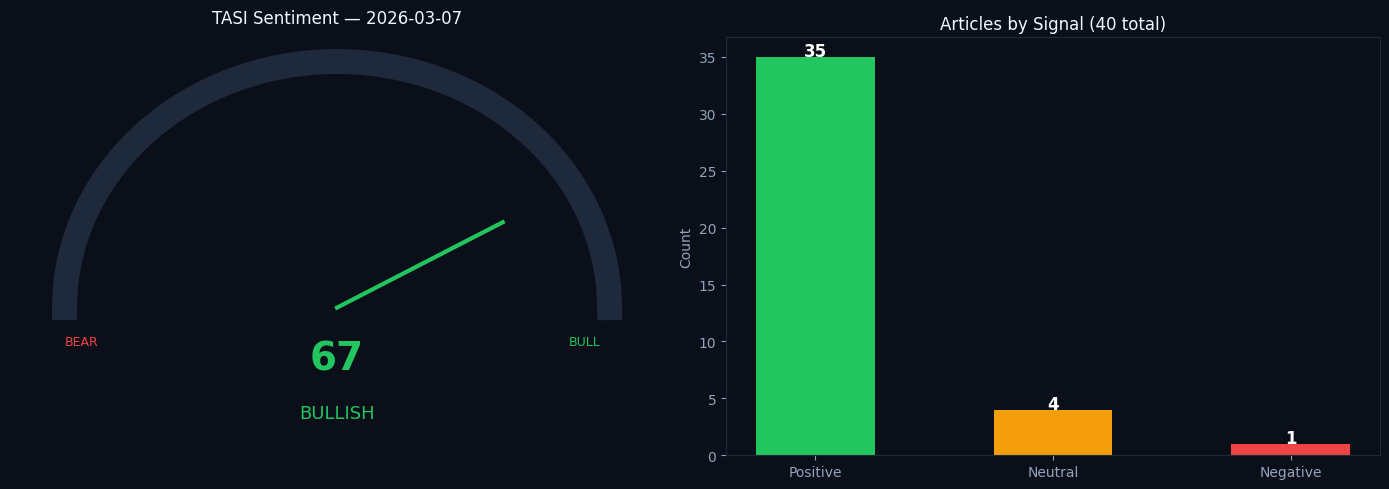

✅ Chart saved


In [6]:
# Block 6: Sentiment Chart
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

today = datetime.now().strftime("%Y-%m-%d")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0a0f1a")

# Gauge
ax1 = axes[0]
ax1.set_facecolor("#0a0f1a")
color = "#22c55e" if final_score > 15 else "#ef4444" if final_score < -15 else "#f59e0b"
theta = np.linspace(0, np.pi, 200)
ax1.plot(np.cos(theta), np.sin(theta), color="#1e293b", linewidth=18)
needle_angle = np.pi * (1 - (final_score + 100) / 200)
ax1.plot([0, 0.7*np.cos(needle_angle)], [0, 0.7*np.sin(needle_angle)], color=color, linewidth=3)
ax1.text(0, -0.25, str(final_score), ha="center", fontsize=28, color=color, fontweight="bold")
ax1.text(0, -0.45, sentiment_label.upper(), ha="center", fontsize=13, color=color)
ax1.text(-1, -0.15, "BEAR", fontsize=9, color="#ef4444")
ax1.text(0.85, -0.15, "BULL", fontsize=9, color="#22c55e")
ax1.set_xlim(-1.2, 1.2); ax1.set_ylim(-0.6, 1.1); ax1.axis("off")
ax1.set_title("TASI Sentiment — " + today, color="#f0f9ff", fontsize=12, pad=10)

# Bar chart
ax2 = axes[1]
ax2.set_facecolor("#0a0f1a")
cats   = ["Positive", "Neutral", "Negative"]
counts = [positive_count, neutral_count, negative_count]
colors = ["#22c55e", "#f59e0b", "#ef4444"]
bars   = ax2.bar(cats, counts, color=colors, width=0.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(count), ha="center", color="white", fontsize=12, fontweight="bold")
ax2.set_title("Articles by Signal (" + str(len(articles)) + " total)", color="#f0f9ff", fontsize=12)
ax2.set_ylabel("Count", color="#94a3b8")
ax2.tick_params(colors="#94a3b8")
for spine in ax2.spines.values(): spine.set_color("#1e293b")

plt.tight_layout()
plt.savefig("tasi_sentiment_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ Chart saved")

In [7]:
# Block 7: Save to CSV
import pandas as pd
from datetime import datetime
from IPython.display import display

today    = datetime.now().strftime("%Y-%m-%d")
CSV_PATH = "tasi_sentiment_daily.csv"

new_row = pd.DataFrame([{
    "date"             : today,
    "score"            : final_score,
    "sentiment"        : sentiment_label,
    "confidence"       : confidence,
    "sentiment_encoded": 1 if sentiment_label=="Bullish" else -1 if sentiment_label=="Bearish" else 0,
    "positive_articles": positive_count,
    "negative_articles": negative_count,
    "neutral_articles" : neutral_count,
    "total_articles"   : len(articles),
    "arabic_articles"  : ar_count,
    "english_articles" : en_count,
    "data_quality"     : data_quality,
}])

try:
    df_existing = pd.read_csv(CSV_PATH)
    df_existing = df_existing[df_existing["date"] != today]
    df_out = pd.concat([df_existing, new_row], ignore_index=True)
except FileNotFoundError:
    df_out = new_row

df_out.to_csv(CSV_PATH, index=False)

print("="*50)
print("✅ SAVED: " + CSV_PATH)
print("   Total days in history: " + str(len(df_out)))
print("="*50)
display(df_out.tail(5))

from google.colab import files
files.download(CSV_PATH)
print("📥 Download started!")

✅ SAVED: tasi_sentiment_daily.csv
   Total days in history: 1


,date,score,sentiment,confidence,sentiment_encoded,positive_articles,negative_articles,neutral_articles,total_articles,arabic_articles,english_articles,data_quality
0,2026-03-07,67,Bullish,69,1,35,1,4,40,34,6,High


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started!


In [ ]:
# Block 8: How to Add Sentiment to LSTM_MODEL.ipynb
print("""
========================================================
HOW TO USE IN LSTM_MODEL.ipynb
========================================================
Add this in Block 2 after loading TASI data:

  df_sent = pd.read_csv('tasi_sentiment_daily.csv', parse_dates=['date'])
  df_sent = df_sent.set_index('date')
  df = df.join(df_sent[['score','confidence','sentiment_encoded']], how='left')
  df[['score','confidence','sentiment_encoded']] = df[['score','confidence','sentiment_encoded']].ffill()
  df.fillna(0, inplace=True)

Then add 'score', 'confidence', 'sentiment_encoded'
to your features list in Block 4.
========================================================
""")